<a href="https://colab.research.google.com/github/asipnana/ProjectNLP/blob/main/notebooks/01_eda_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [4]:
#Import semua yang diperlukan dulu kings and kweens
#Import all needed libraries
import kagglehub, os, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings('ignore')

In [5]:
#Upload data nya dari kaggle agar recreateable
#Upload data from kaggle for recreatability

path = kagglehub.dataset_download("jocelyndumlao/prdect-id-indonesian-emotion-classification")
# Check path yang digunakan untuk download dataset from kaggle
print("Path to dataset files:", path)

# Check the path to confirm file and foldername
for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))
# Confirm and Load path for data
print(path)
df = pd.read_csv(f'{path}/Product Reviews Dataset for Emotions Classification Tasks - Indonesian (PRDECT-ID) Dataset/PRDECT-ID Dataset.csv')


Using Colab cache for faster access to the 'prdect-id-indonesian-emotion-classification' dataset.
Path to dataset files: /kaggle/input/prdect-id-indonesian-emotion-classification
/kaggle/input/prdect-id-indonesian-emotion-classification/Product Reviews Dataset for Emotions Classification Tasks - Indonesian (PRDECT-ID) Dataset/PRDECT-ID Dataset.csv
/kaggle/input/prdect-id-indonesian-emotion-classification


In [6]:
print(df.shape)
df.info()
df.columns

(5400, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         5400 non-null   object 
 1   Product Name     5400 non-null   object 
 2   Location         5400 non-null   object 
 3   Price            5400 non-null   int64  
 4   Overall Rating   5400 non-null   float64
 5   Number Sold      5400 non-null   int64  
 6   Total Review     5400 non-null   int64  
 7   Customer Rating  5400 non-null   int64  
 8   Customer Review  5400 non-null   object 
 9   Sentiment        5400 non-null   object 
 10  Emotion          5400 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 464.2+ KB


Index(['Category', 'Product Name', 'Location', 'Price', 'Overall Rating',
       'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review',
       'Sentiment', 'Emotion'],
      dtype='object')

- Column : 11
- Row : 5400

Datatype : float64(1), int64(4), object(6)

Available Columns : 'Category', 'Product Name', 'Location', 'Price', 'Overall Rating','Number Sold', 'Total Review', 'Customer Rating', 'Customer Review','Sentiment', 'Emotion'

Banyak kolom dari setiap data, dan di EDA ini kita harus melihat relasi dan memfilter column yang akan di drop dan digunakan sebagai fitur.

Dilakukan pemeriksaan struktur data, distribusi fitur, kualitas data (missing values dan duplicate), serta hubungan antar variabel. Hasil analisis ini digunakan untuk menentukan fitur yang relevan, mengidentifikasi fitur yang dapat dihapus, dan memahami karakteristik dataset sebelum tahap preprocessing dan pemodelan.

In [7]:
# simpan raw sebelum cleaning untuk bandingin
df_raw = df.copy()

# cek missing values sebelum cleaning
print(df_raw.isnull().sum())
print()
# cek duplikat
print(f'Duplikat: {df_raw.duplicated(subset=["Customer Review"]).sum()}')

Category           0
Product Name       0
Location           0
Price              0
Overall Rating     0
Number Sold        0
Total Review       0
Customer Rating    0
Customer Review    0
Sentiment          0
Emotion            0
dtype: int64

Duplikat: 95


tidak ada missing value, ada 95 row duplikat.

Akan dilakukan basic cleaning (drop duplicate, normalize sentiment dan emotion dengan lower dan strip).

In [8]:
df.columns        = df.columns.str.strip()
df['Sentiment']   = df['Sentiment'].str.lower().str.strip()
df['Emotion']     = df['Emotion'].str.lower().str.strip()

In [9]:
df     = df.drop_duplicates(subset=['Customer Review']).reset_index(drop=True)

# Check shape dari raw dan cleaned.
print(f'Raw shape   : {df_raw.shape}')
print(f'Clean shape : {df.shape}')
print(f'Dropped     : {len(df_raw) - len(df)} rows')

df.head()

Raw shape   : (5400, 11)
Clean shape : (5305, 11)
Dropped     : 95 rows


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,positive,happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",positive,happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",positive,happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,positive,happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",positive,happy


In [10]:
df_raw.head()

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


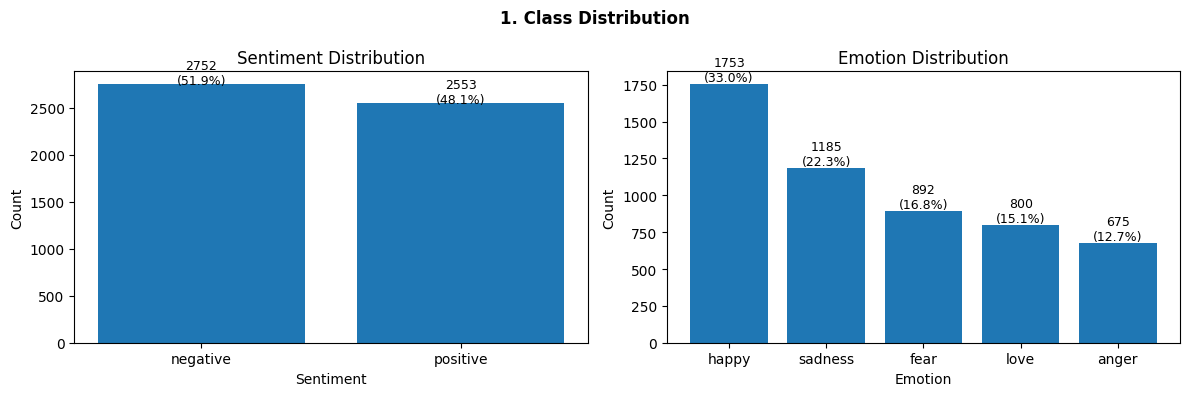

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('1. Class Distribution', fontweight='bold')

# Lihat kolom Sentiment dan Emotion untuk melihat distribusinya
# Sentiment :
sent_counts = df['Sentiment'].value_counts()

bars = ax[0].bar(sent_counts.index, sent_counts.values)
for bar, val in zip(bars, sent_counts.values):
    ax[0].text(
        # Naro percentage tengah grafik agar terlihat
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{val}\n({val/len(df)*100:.1f}%)',
        ha='center',
        fontsize=9
    )

ax[0].set_title('Sentiment Distribution')
ax[0].set_xlabel('Sentiment')
ax[0].set_ylabel('Count')
# Emotion :
emotion_counts = df['Emotion'].value_counts()

bars = ax[1].bar(emotion_counts.index, emotion_counts.values)
for bar, val in zip(bars, emotion_counts.values):
    ax[1].text(
        # Naro percentage tengah grafik agar terlihat
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f'{val}\n({val/len(df)*100:.1f}%)',
        ha='center',
        fontsize=9
    )

ax[1].set_title('Emotion Distribution')
ax[1].set_xlabel('Emotion')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

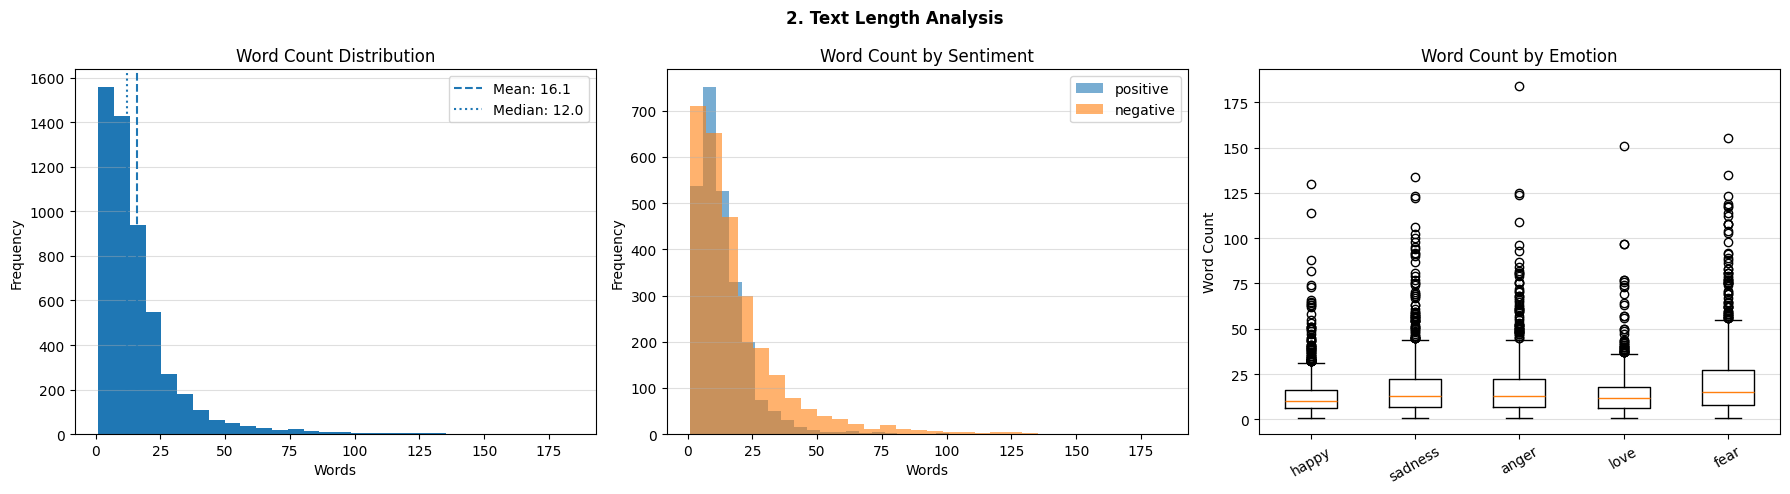

            count   mean    std  min  25%   50%   75%    max
Sentiment                                                   
negative   2752.0  19.01  18.35  1.0  7.0  14.0  24.0  184.0
positive   2553.0  13.05  11.02  1.0  6.0  10.0  17.0  151.0


In [12]:
df['word_count'] = df['Customer Review'].str.split().str.len()
df['char_len']   = df['Customer Review'].str.len()

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2. Text Length Analysis', fontweight='bold')
# Overall Word Count Distribution
ax[0].hist(df['word_count'], bins=30)

ax[0].axvline(
    df['word_count'].mean(),
    linestyle='--',
    label=f'Mean: {df["word_count"].mean():.1f}'
)

ax[0].axvline(
    df['word_count'].median(),
    linestyle=':',
    label=f'Median: {df["word_count"].median():.1f}'
)

ax[0].set_title('Word Count Distribution')
ax[0].set_xlabel('Words')
ax[0].set_ylabel('Frequency')
ax[0].legend()
ax[0].grid(axis='y', alpha=0.4)

# Word Count by Sentiment
for sentiment in df['Sentiment'].unique():
    subset = df[df['Sentiment'] == sentiment]['word_count']

    ax[1].hist(
        subset,
        bins=30,
        alpha=0.6,
        label=sentiment
    )

ax[1].set_title('Word Count by Sentiment')
ax[1].set_xlabel('Words')
ax[1].set_ylabel('Frequency')
ax[1].legend()
ax[1].grid(axis='y', alpha=0.4)

# Word Count by Emotion
emotions = df['Emotion'].unique()
data_emo = [
    df[df['Emotion'] == e]['word_count'].values
    for e in emotions
]

ax[2].boxplot(
    data_emo,
    tick_labels=emotions,
    patch_artist=False
)

ax[2].set_title('Word Count by Emotion')
ax[2].tick_params(axis='x', rotation=30)
ax[2].set_ylabel('Word Count')
ax[2].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

print(
    df.groupby('Sentiment')['word_count']
      .describe()
      .round(2)
)

Review negatif cenderung lebih panjang, terlihat pada mean, median nya, dan kedua review memiliki nilai makasimal yang cukup tinggi sehingga akan terlihat outlier.

**Remove Stopwords untuk keperluan visualisasi wordcloud dan menemukan kata kata penting pada kedua sentimen.**

In [13]:
!pip install PySastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 6.7 MB/s eta 0:00:00


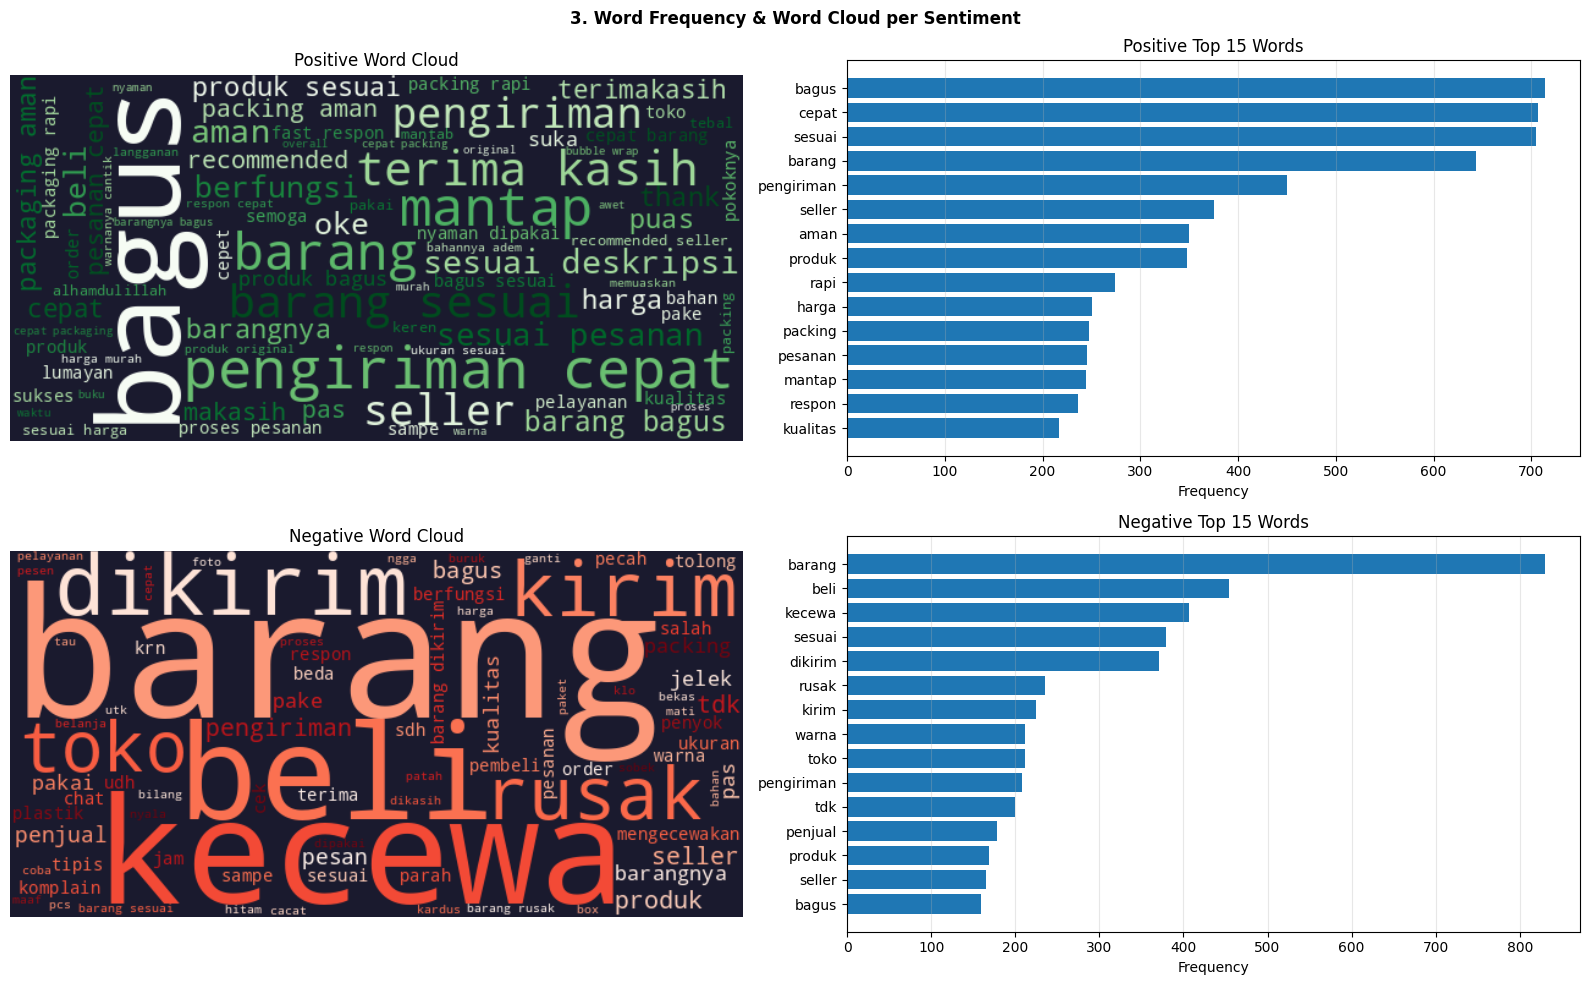

In [14]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
base_stopwords = set(factory.get_stop_words())

custom_stopwords = {
    'yang','dan','di','ke','dari','ini','itu','untuk','dengan','pada','tidak',
    'ada','saya','aku','kamu','kita','mereka','dia','adalah','juga','sudah',
    'bisa','kalau','atau','karena','tapi','ya','yg','dgn','tak','gak','nggak',
    'ga','udah','aja','deh','sih','lah','kalo','emang','banget','bgt','yah',
    'lagi','nih','dong','kan','nya','http','https','rt','amp','juga',
    'sangat', 'sangat','sekali','paling','lebih','kurang','cukup','sudah','belum'
}


ID_STOPWORDS = base_stopwords | custom_stopwords


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def get_tokens(series):
    words = ' '.join(series.apply(clean_text)).split()
    return [w for w in words if w not in ID_STOPWORDS and len(w) >= 3]


df['clean_text'] = df['Customer Review'].apply(clean_text)

fig, ax = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('3. Word Frequency & Word Cloud per Sentiment', fontweight='bold')
# Membuat word frequency dan word cloud untuk sentimen positif dan negatif

for i, sentiment in enumerate(['positive', 'negative']):

    subset = df[df['Sentiment'] == sentiment]['Customer Review']
    tokens = get_tokens(subset)

    # Word Cloud
    wc = WordCloud(
        width=600,
        height=300,
        background_color='#1a1a2e', #Kalo item kurang swag, putih gakeliatan
         colormap='Greens' if sentiment == 'positive' else 'Reds',
        max_words=80
    ).generate(' '.join(tokens))

    ax[i][0].imshow(wc, interpolation='bilinear')
    ax[i][0].axis('off')
    ax[i][0].set_title(f'{sentiment.title()} Word Cloud')

    # Top 15 Words
    top = Counter(tokens).most_common(15)
    words, counts = zip(*top)

    ax[i][1].barh(words[::-1], counts[::-1])
    ax[i][1].set_title(f'{sentiment.title()} Top 15 Words')
    ax[i][1].set_xlabel('Frequency')
    ax[i][1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


Setelah terlihat wordcloudnya memang ada beberapa kata yang sama, contohnya kata "barang" ada dengan jumlah yang sama-sama besar di positif dan negatif. Kata tersebut lebih merepresentasikan konteks produk yang dibahas daripada sentimen tertentu.

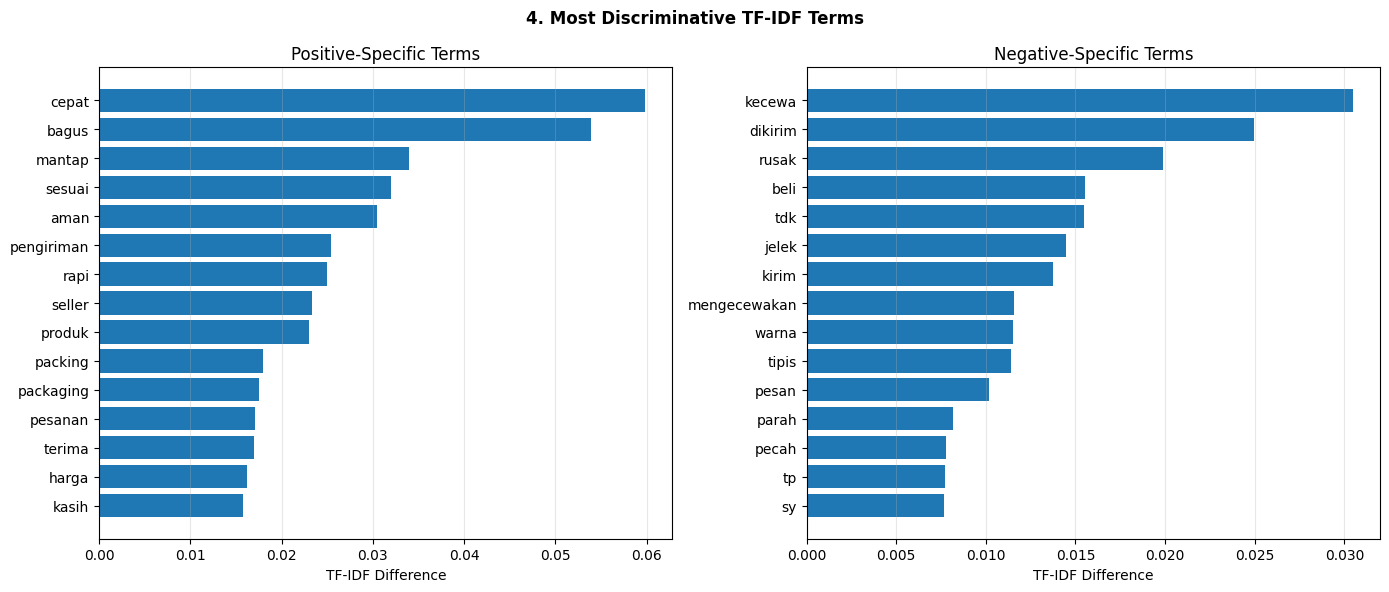

In [15]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words=list(ID_STOPWORDS),
    min_df=2
)

tfidf_matrix = tfidf.fit_transform(df['clean_text'])
feature_names = tfidf.get_feature_names_out()

# Mean TF-IDF tiap class
pos_mask = (df['Sentiment'] == 'positive').values
neg_mask = (df['Sentiment'] == 'negative').values

pos_mean = tfidf_matrix[pos_mask].mean(axis=0).A1
neg_mean = tfidf_matrix[neg_mask].mean(axis=0).A1

# Skor diskriminatif
pos_diff = pos_mean - neg_mean
neg_diff = neg_mean - pos_mean

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('4. Most Discriminative TF-IDF Terms', fontweight='bold')
# Cari kata paling membedakan review positif dengan negatif
# Positive-specific words
top_pos = pos_diff.argsort()[::-1][:15]

ax[0].barh(
    feature_names[top_pos][::-1],
    pos_diff[top_pos][::-1]
)

ax[0].set_title('Positive-Specific Terms')
ax[0].set_xlabel('TF-IDF Difference')
ax[0].grid(axis='x', alpha=0.3)

# Negative-specific words
top_neg = neg_diff.argsort()[::-1][:15]

ax[1].barh(
    feature_names[top_neg][::-1],
    neg_diff[top_neg][::-1]
)

ax[1].set_title('Negative-Specific Terms')
ax[1].set_xlabel('TF-IDF Difference')
ax[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Kata "barang" yang sebelumnya paling dominan pada analisis frekuensi tidak lagi muncul. Hal ini menunjukkan bahwa kata tersebut merupakan kata umum dalam domain e-commerce dan kurang efektif untuk membedakan sentimen pelanggan. Kata-kata seperti "kecewa", "rusak", "bagus", dan "cepat" memiliki daya diskriminasi yang jauh lebih tinggi dalam klasifikasi sentimen.

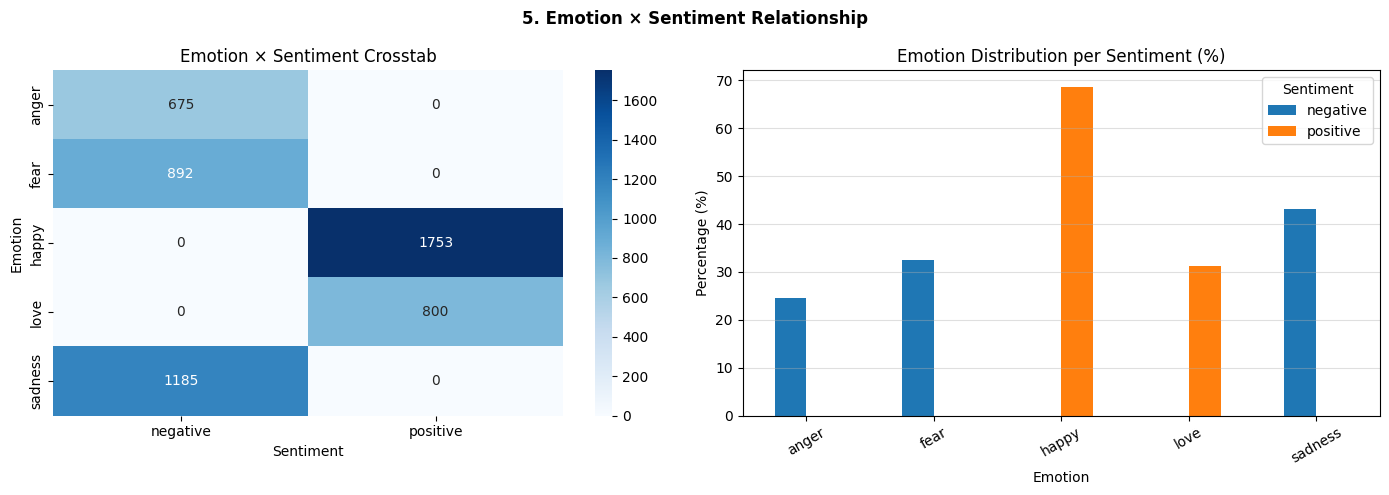

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5. Emotion × Sentiment Relationship', fontweight='bold')
# Melihat hubungan antara emosi dan sentimen

# Heatmap
ct = pd.crosstab(df['Emotion'], df['Sentiment'])

sns.heatmap(
    ct,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0]
)

ax[0].set_title('Emotion × Sentiment Crosstab')

# Emotion breakdown tiap sentiment
ct_pct = (
    pd.crosstab(
        df['Emotion'],
        df['Sentiment'],
        normalize='columns'
    ) * 100
)

ct_pct.plot(
    kind='bar',
    ax=ax[1]
)

ax[1].set_title('Emotion Distribution per Sentiment (%)')
ax[1].set_xlabel('Emotion')
ax[1].set_ylabel('Percentage (%)')
ax[1].tick_params(axis='x', rotation=30)
ax[1].legend(title='Sentiment')
ax[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

Dari heatmap terlihat semua emosi dengan sentimen terpisah sempurna. Dataset memiliki hubungan yang sangat kuat antara label emotion dan sentiment. Emotion mengandung informasi yang hampir sepenuhnya menentukan sentiment.

Temuan ini menunjukkan bahwa label emosi mengandung informasi sentimen yang sangat kuat. Oleh karena itu, kolom Emotion tidak digunakan sebagai fitur dalam model sentiment analysis untuk menghindari label leakage. Namun, label tersebut tetap menarik untuk dieksplorasi dalam eksperimen multi-task learning atau emotion classification.

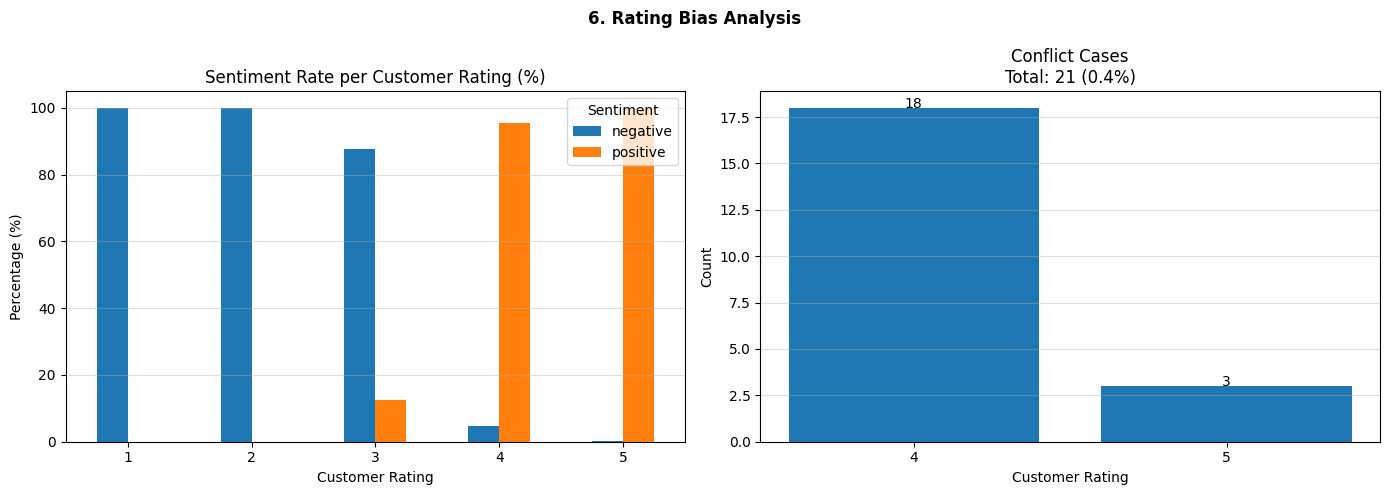

Contoh Conflict : 


,Customer Rating,Sentiment,Customer Review
5039,4,negative,Tidak komunikatif. Wrn yg di pilih ga ada. Sdh...
5045,4,negative,pengemasan perlu ditingkatkan
5032,4,negative,Ada 1 shade yg salah kirim
1390,5,negative,Lambat
5018,4,negative,baru sekali pake pas dicuci robek ??


In [17]:
df['rating_bin'] = df['Customer Rating'].apply(
    lambda x: 'high (4-5)' if x >= 4
    else ('low (1-2)' if x <= 2 else 'mid (3)')
)

conflict = df[
    ((df['rating_bin'] == 'high (4-5)') & (df['Sentiment'] == 'negative')) |
    ((df['rating_bin'] == 'low (1-2)') & (df['Sentiment'] == 'positive'))
]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('6. Rating Bias Analysis', fontweight='bold')
# Melihat konsistensi Rating dengan Sentiment

# Sentiment per Rating
ct2 = (
    pd.crosstab(
        df['Customer Rating'],
        df['Sentiment'],
        normalize='index'
    ) * 100
)

ct2.plot(
    kind='bar',
    ax=ax[0]
)

ax[0].set_title('Sentiment Rate per Customer Rating (%)')
ax[0].set_xlabel('Customer Rating')
ax[0].set_ylabel('Percentage (%)')
ax[0].tick_params(axis='x', rotation=0)
ax[0].legend(title='Sentiment')
ax[0].grid(axis='y', alpha=0.4)

# Conflict Cases
conflict_by_rating = (
    conflict['Customer Rating']
    .value_counts()
    .sort_index()
)

bars = ax[1].bar(
    conflict_by_rating.index.astype(str),
    conflict_by_rating.values
)

ax[1].set_title(
    f'Conflict Cases\nTotal: {len(conflict)} ({len(conflict)/len(df)*100:.1f}%)'
)

ax[1].set_xlabel('Customer Rating')
ax[1].set_ylabel('Count')
ax[1].grid(axis='y', alpha=0.4)

for bar, val in zip(bars, conflict_by_rating.values):
    ax[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(val),
        ha='center'
    )

plt.tight_layout()
plt.show()

print("Contoh Conflict : ")
conflict[
    ['Customer Rating', 'Sentiment', 'Customer Review']
].sample(5)

Sebagian besar customer rating konsisten dengan label sentimen, kualitas anotasi dataset cukup baik.

Ada sejumlah kecil conflict cases (~0.4%),
yaitu review dengan rating tinggi tetapi sentiment negatif,
atau rating rendah tetapi sentiment positif.

Customer Rating memiliki korelasi yang sangat kuat dengan Sentiment.
Customer Rating sebagai fitur
berpotensi menyebabkan shortcut learning.

Untuk sentiment analysis berbasis teks, Customer Rating tidak kami gunakan sebagai feature utama.

In [18]:
print('7. EDA SUMMARY & COLUMN SELECTION JUSTIFICATION')

sent_counts = df['Sentiment'].value_counts()
imb         = sent_counts.max() / sent_counts.min()

print(f'''
Dataset
Total samples     : {len(df):,}
Columns           : {df.shape[1]}

Label Distribution
Sentiment         : {dict(sent_counts)}
Imbalance ratio   : {imb:.2f}x → {"relatively balanced" if imb <= 1.5 else "imbalanced"}
Emotion classes   : {df["Emotion"].nunique()} → {list(df["Emotion"].unique())}

Text Characteristics
Avg word count    : {df["word_count"].mean():.1f} words/review
Median word count : {df["word_count"].median():.1f} words/review
Max word count    : {df["word_count"].max()} words

Rating Bias
Conflict rate     : {len(conflict)/len(df)*100:.1f}% → rating mostly aligned with sentiment

SELECTED COLUMNS
Customer Review   -> main text feature
Sentiment         -> primary target

DROPPED COLUMNS
Emotion           -> auxiliary analysis / additional task
Customer Rating   -> highly correlated with sentiment
Category          -> sentiment distribution relatively similar across categories
Overall Rating    -> product-level aggregate rating
Price             -> product metadata
Location          -> product metadata
Number Sold       -> product metadata
Total Review      -> product metadata
Product Name      -> less relevant for text-based sentiment analysis
''')

7. EDA SUMMARY & COLUMN SELECTION JUSTIFICATION

Dataset
Total samples     : 5,305
Columns           : 15

Label Distribution
Sentiment         : {'negative': np.int64(2752), 'positive': np.int64(2553)}
Imbalance ratio   : 1.08x → relatively balanced
Emotion classes   : 5 → ['happy', 'sadness', 'anger', 'love', 'fear']

Text Characteristics
Avg word count    : 16.1 words/review
Median word count : 12.0 words/review
Max word count    : 184 words

Rating Bias
Conflict rate     : 0.4% → rating mostly aligned with sentiment

SELECTED COLUMNS
Customer Review   -> main text feature
Sentiment         -> primary target

DROPPED COLUMNS
Emotion           -> auxiliary analysis / additional task
Customer Rating   -> highly correlated with sentiment
Category          -> sentiment distribution relatively similar across categories
Overall Rating    -> product-level aggregate rating
Price             -> product metadata
Location          -> product metadata
Number Sold       -> product metadata
Total

## EDA Summary

Dataset terdiri dari 5.305 review dengan distribusi sentiment yang relatif seimbang antara kelas positif dan negatif. Dataset juga memiliki 5 kategori emosi: happy, love, anger, fear, dan sadness.

Hasil analisis menunjukkan bahwa review negatif cenderung lebih panjang dibanding review positif, yang mengindikasikan pelanggan tidak puas biasanya memberikan penjelasan lebih detail.

Analisis kata dan TF-IDF menunjukkan bahwa:
- sentiment positif didominasi kata seperti *bagus*, *cepat*, *mantap*, dan *sesuai*,
- sedangkan sentiment negatif banyak mengandung kata seperti *kecewa*, *rusak*, *jelek*, dan *mengecewakan*.

Hubungan antara emotion dan sentiment sangat kuat:
- happy dan love → positif,
- anger, fear, dan sadness → negatif.

Karena itu, kolom `Emotion` tidak digunakan sebagai input model untuk menghindari label leakage.

Analisis rating juga menunjukkan bahwa customer rating sangat konsisten dengan sentiment, dengan conflict case hanya sekitar 0.4%. Hal ini menandakan kualitas label dataset cukup baik, namun `Customer Rating` tidak digunakan sebagai fitur karena terlalu berkorelasi dengan target sentiment.

Berdasarkan hasil EDA, fitur utama yang digunakan untuk sentiment analysis adalah:
- `Customer Review` sebagai input teks,
- `Sentiment` sebagai target utama.

Sementara kolom metadata produk seperti `Price`, `Location`, `Number Sold`, dan `Product Name` tidak digunakan karena kurang relevan untuk analisis sentiment berbasis teks.